In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Count county rows

In [2]:
df = pd.read_csv('county_row_counts.csv')

In [4]:
df['row_count'].describe()

count      2850.000000
mean       7418.944211
std       19471.366473
min           1.000000
25%         689.500000
50%        1971.500000
75%        5713.000000
max      499748.000000
Name: row_count, dtype: float64

In [6]:
df.sort_values('row_count', ascending=True).head(10)

,fips,filename,row_count,file_size_bytes,file_size_mb
932,21099,fips_21099.csv,1,3304,0.0
1296,28057,fips_28057.csv,1,3349,0.0
1331,28145,fips_28145.csv,1,3338,0.0
2400,48269,fips_48269.csv,1,3215,0.0
2329,48111,fips_48111.csv,1,3309,0.0
2829,56005,fips_56005.csv,1,3315,0.0
1336,28157,fips_28157.csv,2,4158,0.0
65,2060,fips_2060.csv,2,3043,0.0
40,1087,fips_1087.csv,2,4209,0.0
78,2261,fips_2261.csv,2,3084,0.0


In [11]:
df[(df['row_count'] >= 10) & (df['row_count'] <= 100)].shape

(101, 5)

In [7]:
df

,fips,filename,row_count,file_size_bytes,file_size_mb
0,1001,fips_1001.csv,5342,4483063,4.28
1,1003,fips_1003.csv,26446,22800791,21.74
2,1005,fips_1005.csv,608,527759,0.50
3,1007,fips_1007.csv,656,564273,0.54
4,1009,fips_1009.csv,3541,3043710,2.90
...,...,...,...,...,...
2845,56041,fips_56041.csv,674,586255,0.56
2846,56043,fips_56043.csv,589,505186,0.48
2847,78010,fips_78010.csv,223,81227,0.08
2848,78020,fips_78020.csv,51,20556,0.02


# See tree-based results

In [2]:
df = pd.read_csv('/nlp/scr/salilg/corelogic_census_2018_2023.csv', nrows=100000)

/tmp/user/24606/ipykernel_3708225/1200491761.py:1: DtypeWarning: Columns (82,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/nlp/scr/salilg/corelogic_census_2018_2023.csv', nrows=100000)


In [3]:
# results = pd.read_csv('/oak/stanford/groups/deho/proptax/models/census_loop_bg_only/results/census_loop_rf_bg_only_results.csv')
tree_results = pd.read_csv('/nlp/scr/salilg/census_loop_rf_bg_only_results.csv')
tree_results.shape

(3090686, 20)

In [4]:
df = tree_results[tree_results['fips']=='17031']
df.shape

(0, 20)

In [5]:
tree_results['fips'].value_counts()

fips
4013     83753
32003    43103
17031    36505
48201    35445
48029    24851
         ...  
30059       15
35047       12
45041        5
45079        3
51167        2
Name: count, Length: 2514, dtype: int64

## compare to tabpfn

In [10]:
tabpfn_results = pd.read_csv('results.csv')

In [12]:
tabpfn_results

,meta_sfh,ASSESSED_YEAR,SALE_YEAR,CLIP,fips,tract,block_group,MARKET_TOTAL_VALUE,ASSESSED_TOTAL_VALUE,APPRAISED_TOTAL_VALUE,...,CALCULATED_TOTAL_VALUE_SOURCE_CODE,TOTAL_TAX_AMOUNT,NET_TAX_AMOUNT,latitude,longitude,y_true,y_pred,ratio,model_id,n_train_samples
0,1,2023,2023,1199126204,1003,11604,116041,98100.0,9820.0,98100.0,...,M,269.24,NaN,30.347580,-87.501208,164000.0,182303.86,1.111609,tabpfn,130
1,1,2023,2023,9745724995,1003,10706,107062,254800.0,25500.0,254800.0,...,M,918.00,NaN,30.667595,-87.881723,185000.0,280687.25,1.517228,tabpfn,130
2,1,2023,2023,3936139524,1003,11409,114091,153100.0,15320.0,153100.0,...,M,383.96,NaN,30.427702,-87.818854,249900.0,178734.44,0.715224,tabpfn,130
3,1,2023,2023,8569174164,1003,10711,107111,141700.0,14180.0,141700.0,...,M,652.28,NaN,30.641236,-87.909494,220147.0,177860.40,0.807917,tabpfn,130
4,1,2023,2023,1018152976,1003,10708,107084,510900.0,51100.0,510900.0,...,M,1845.70,NaN,30.679487,-87.813739,542500.0,417127.30,0.768898,tabpfn,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1361,1,2023,2023,4522473965,5007,20704,207041,370450.0,74090.0,NaN,...,M,1994.94,NaN,36.422063,-94.168906,637500.0,675129.60,1.059027,tabpfn,164
1362,1,2023,2023,4783417679,5021,950100,9501001,97100.0,19420.0,NaN,...,M,40.22,NaN,36.258762,-90.160731,87878.0,76572.45,0.871350,tabpfn,6
1363,1,2023,2023,3425589505,5021,950500,9505001,29100.0,5820.0,NaN,...,M,311.31,NaN,36.262395,-90.290077,36000.0,75409.28,2.094702,tabpfn,6
1364,1,2023,2023,6102932678,5037,950600,9506003,92400.0,18480.0,NaN,...,M,489.76,NaN,35.229099,-90.777843,145000.0,142913.50,0.985610,tabpfn,9


In [26]:
merged = pd.merge_asof(tabpfn_results.sort_values('y_true'), tree_results.sort_values('y_true'), on='y_true', by='CLIP', tolerance=1e-6)

In [31]:
compare = merged[['CLIP', 'fips_x', 'ASSESSED_YEAR_x', 'y_true', 'y_pred_x', 'ratio_x', 'y_pred_y', 'ratio_y']].dropna()

In [32]:
compare

,CLIP,fips_x,ASSESSED_YEAR_x,y_true,y_pred_x,ratio_x,y_pred_y,ratio_y
1,7646414874,1003,2023,49000.0,483289.10,9.863043,4.609914e+05,9.407988
6,3930558594,4021,2023,68580.0,273994.80,3.995258,1.823071e+05,2.658313
9,8288113193,1101,2023,85012.0,142161.10,1.672247,1.301795e+05,1.531308
10,2417650044,4021,2023,86500.0,157403.25,1.819691,1.599398e+05,1.849015
13,8552708010,1101,2023,90000.0,178315.30,1.981281,9.597168e+04,1.066352
...,...,...,...,...,...,...,...,...
1358,4195015695,4013,2022,1700000.0,2024695.40,1.190997,1.562078e+06,0.918869
1360,5397318148,4013,2022,1740000.0,2212482.20,1.271542,1.729384e+06,0.993899
1363,4601927687,4013,2022,1850000.0,2290358.80,1.238032,1.664698e+06,0.899837
1364,8214023976,4013,2022,2000000.0,2128272.20,1.064136,1.552224e+06,0.776112


In [24]:
tree_results[tree_results['CLIP']=='4491515104']

,meta_sfh,ASSESSED_YEAR,SALE_YEAR,CLIP,fips,tract,block_group,MARKET_TOTAL_VALUE,ASSESSED_TOTAL_VALUE,APPRAISED_TOTAL_VALUE,CALCULATED_TOTAL_VALUE,CALCULATED_TOTAL_VALUE_SOURCE_CODE,TOTAL_TAX_AMOUNT,NET_TAX_AMOUNT,latitude,longitude,y_true,y_pred,ratio,model_id


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [33]:
mean_absolute_error(compare['y_true'], compare['y_pred_x']), mean_absolute_error(compare['y_true'], compare['y_pred_y'])

(110271.12553162855, 83308.64767397437)

In [34]:
mean_squared_error(compare['y_true'], compare['y_pred_x']), mean_squared_error(compare['y_true'], compare['y_pred_y'])

(23943315624.962677, 14455441887.601526)

In [35]:
r2_score(compare['y_true'], compare['y_pred_x']), r2_score(compare['y_true'], compare['y_pred_y'])

(0.6276757211570724, 0.7752144247496852)

In [36]:
compare['ratio_x'].mean(), compare['ratio_y'].mean()

(np.float64(1.1612444311229644), np.float64(1.0069832321057304))

In [37]:
tabpfn_results['fips'].unique()

array([1003, 1021, 1089, 1101, 1117, 2020, 4009, 4013, 4019, 4021, 5007,
       5021, 5037])

In [38]:
tabpfn_results['fips'].value_counts()

fips
4013    937
4019    135
4021    130
1089     41
1003     35
5007     26
1117     22
1101     18
2020     12
1021      3
4009      3
5021      2
5037      2
Name: count, dtype: int64

# Look at cook county

In [6]:
df = pd.read_csv('cook_county.csv')

/tmp/user/24606/ipykernel_2700526/746897951.py:1: DtypeWarning: Columns (53) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('cook_county.csv')


In [7]:
df.shape

(211528, 143)

In [11]:
df[['block_group', 'block_group_id', 'fips']]

,block_group,block_group_id,fips
0,8107011.0,1.703181e+11,17031.0
1,8041041.0,1.703180e+11,17031.0
2,8300051.0,1.703183e+11,17031.0
3,6108001.0,1.703161e+11,17031.0
4,8207001.0,1.703182e+11,17031.0
...,...,...,...
211523,8260002.0,1.703183e+11,17031.0
211524,8300043.0,1.703183e+11,17031.0
211525,4910001.0,1.703149e+11,17031.0
211526,4910001.0,1.703149e+11,17031.0


In [14]:
df['block_group'].value_counts().describe()

count    3890.000000
mean       54.375321
std        45.708080
min         1.000000
25%        17.000000
50%        45.000000
75%        80.000000
max       442.000000
Name: count, dtype: float64

In [15]:
df['SALE_YEAR'].value_counts()

SALE_YEAR
2021    49364
2020    43866
2022    40333
2018    39099
2019    38866
Name: count, dtype: int64

In [16]:
df['SALE_AMOUNT'].isna().sum()

np.int64(0)

In [22]:
# Identify repeat sales: same CLIP in two different rows with same year and month
# Extract year and month from sale_date
df['sale_year'] = (df['sale_date'] // 10000).astype(int)
df['sale_month'] = ((df['sale_date'] % 10000) // 100).astype(int)

# Find duplicate CLIPs with same year and month
repeat_sales_mask = df.duplicated(subset=['CLIP', 'sale_year', 'sale_month'], keep=False)
repeat_sales = df[repeat_sales_mask].copy()

print(f"Total rows with repeat sales: {len(repeat_sales)}")
print(f"Number of unique CLIPs with repeat sales: {repeat_sales['CLIP'].nunique()}")

# Show the repeat sales, sorted by CLIP and year/month
repeat_sales_sorted = repeat_sales.sort_values(['CLIP', 'sale_year', 'sale_month', 'sale_date'])
repeat_sales_sorted[['CLIP', 'sale_date', 'sale_year', 'sale_month', 'SALE_AMOUNT']].head(20)

Total rows with repeat sales: 2993
Number of unique CLIPs with repeat sales: 1057


,CLIP,sale_date,sale_year,sale_month,SALE_AMOUNT
21203,1000135151,20180409,2018,4,239000.0
50777,1000135151,20180409,2018,4,239000.0
78509,1000178803,20190225,2019,2,50000.0
46748,1000178803,20190227,2019,2,50000.0
34595,1000271887,20211025,2021,10,143500.0
150663,1000271887,20211025,2021,10,159000.0
27185,1000339571,20211008,2021,10,78525.0
129835,1000339571,20211008,2021,10,60000.0
96474,1000798638,20210125,2021,1,484000.0
62810,1000798638,20210129,2021,1,559000.0


In [25]:
df[df['CLIP']==1000135151]

,Unnamed: 0,ASSESSED_YEAR,CENSUS_ID,fips,MARKET_TOTAL_VALUE,latitude,longitude,address,TAX_YEAR,TOTAL_TAX_AMOUNT,...,census_med_hh_inc_bg,census_med_per_cap_inc_bg,census_pct_snap_bg,census_unemp_rate_bg,census_med_yr_built_bg,census_pct_renter_occ_bg,census_med_rent_bg,block_group_id,sale_year,sale_month
21203,2572672,2018,8.239031e+09,17031.0,245410.0,41.668005,-87.820027,19 COMMONS DR,2018.0,6212.07,...,84018.0,41770.0,0.035897,0.096591,1977.0,0.912821,NaN,1.703182e+11,2018,4
50777,6128129,2018,8.239031e+09,17031.0,245410.0,41.668005,-87.820027,19 COMMONS DR,2018.0,6212.07,...,84018.0,41770.0,0.035897,0.096591,1977.0,0.912821,NaN,1.703182e+11,2018,4


# Within-county results for small counties

In [48]:
from pathlib import Path
from glob import glob
import os

In [49]:
results_dir = Path('../results/within_county')
result_files = list(results_dir.glob('county_*_results.csv'))

In [50]:
all_results = []
for file in result_files:

    df = pd.read_csv(file)
    all_results.append(df)

combined_results = pd.concat(all_results, ignore_index=True)

In [51]:
combined_results.columns

Index(['fips', 'bin_name', 'repetition', 'fold', 'model', 'train_size',
       'test_size', 'n_features', 'fit_time', 'pred_time', 'r2', 'mae', 'rmse',
       'mse', 'hyperparam_max_depth', 'hyperparam_learning_rate',
       'hyperparam_n_estimators', 'hyperparam_subsample',
       'hyperparam_colsample_bytree', 'hyperparam_min_child_weight',
       'hyperparam_reg_alpha', 'hyperparam_reg_lambda', 'hyperparam_gamma',
       'tune_time'],
      dtype='object')

In [52]:
df1 = combined_results[combined_results['model']=='tabpfn']
df2 = combined_results[combined_results['model']=='xgboost']

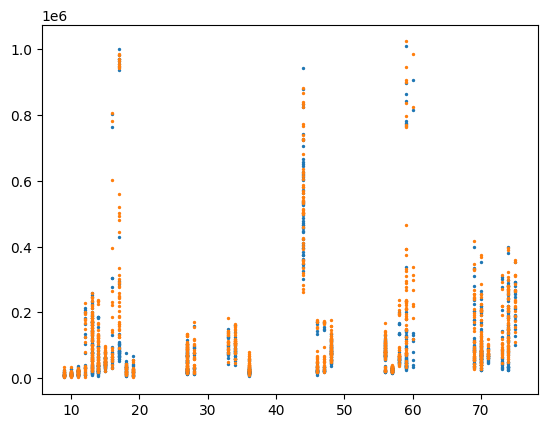

In [30]:
plt.scatter(df1['train_size'], df1['mae'], label='tabpfn', s=2)
plt.scatter(df2['train_size'], df2['mae'], label='xgboost', s=2)

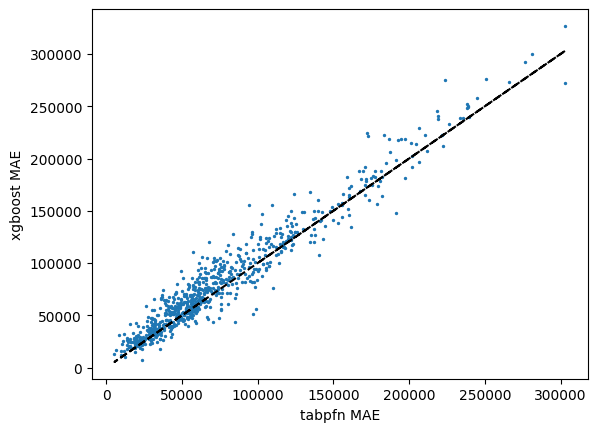

In [7]:
plt.scatter(df1['mae'], df2['mae'], s=2)
plt.xlabel('tabpfn MAE')
plt.ylabel('xgboost MAE')

#J y=x line
plt.plot(df1['mae'], df1['mae'], 'k--')
plt.show()


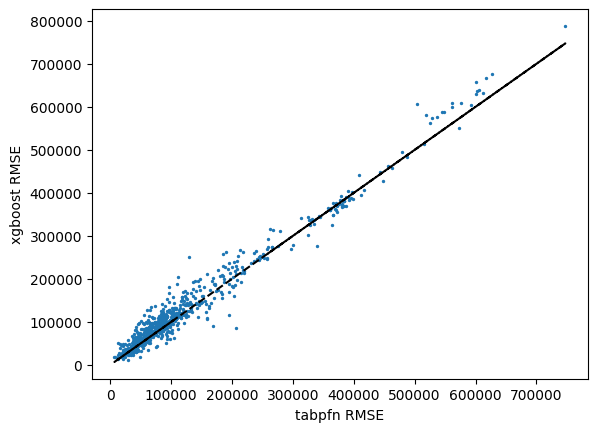

In [8]:
plt.scatter(df1['rmse'], df2['rmse'], s=2)
plt.xlabel('tabpfn RMSE')
plt.ylabel('xgboost RMSE')

#J y=x line
plt.plot(df1['rmse'], df1['rmse'], 'k--')
plt.show()


In [9]:
res1 = df1['mae'].describe()
res2 = df2['mae'].describe()

# put them together
res = pd.concat([res1, res2], axis=1)
res.columns = ['tabpfn', 'xgboost']

with pd.option_context('display.float_format', '{:,.6f}'.format):
    print(res)

              tabpfn        xgboost
count     750.000000     750.000000
mean   75,197.343144  82,189.720426
std    52,202.329842  53,663.381851
min     5,401.450195   7,450.707682
25%    39,287.725626  44,792.983264
50%    60,066.611801  67,518.490859
75%    96,065.700825 102,297.435569
max   303,163.783548 326,852.095217


In [10]:
df1['fips'].nunique(), df2['fips'].nunique()

(15, 15)

In [55]:
fips_list = df1['fips'].unique()
list_of_median_sale_prices = []
county_size = []
for fips in df1['fips'].unique():
    df = pd.read_csv(f'/nlp/scr/salilg/county_csvs/fips_{fips}.csv')
    list_of_median_sale_prices.append(df['SALE_AMOUNT'].median())
    county_size.append(df.shape[0])
saleprices = pd.DataFrame({'fips': fips_list, 'median_sale_price': list_of_median_sale_prices, 'county_size': county_size})

saleprices


,fips,median_sale_price,county_size
0,13101,72050.00,92
1,13307,105000.00,87
2,2100,267250.00,88
3,2275,305625.00,16
4,8061,95000.00,71
5,13007,97600.00,93
6,2016,467780.00,34
7,8033,212500.00,60
8,1011,60000.00,87
9,1041,85300.00,17


In [56]:
with pd.option_context('display.float_format', '{:,.6f}'.format):
    print(saleprices[['median_sale_price', 'county_size']].describe())

       median_sale_price  county_size
count          15.000000    15.000000
mean      177,805.762000    59.133333
std       128,604.390270    29.242500
min        58,225.000000    16.000000
25%        87,650.000000    34.000000
50%       105,000.000000    71.000000
75%       250,150.215000    87.000000
max       467,780.000000    93.000000


# Cross-county results for small counties

In [13]:
from pathlib import Path
from glob import glob
import os

In [30]:
results_dir = Path('../results/cross_county')
result_files = list(results_dir.glob('county_*_results.csv'))
all_results = []
for file in result_files:
    df = pd.read_csv(file)
    all_results.append(df)

In [31]:
combined_results = pd.concat(all_results, ignore_index=True)
combined_results = combined_results.rename(columns={'target_fips': 'fips'})

In [32]:
combined_results.columns

Index(['fips', 'bin_name', 'iteration', 'model', 'train_pool_size',
       'test_size', 'n_features', 'fit_time', 'pred_time', 'r2', 'mae', 'rmse',
       'mse', 'hyperparam_max_depth', 'hyperparam_learning_rate',
       'hyperparam_n_estimators', 'hyperparam_subsample',
       'hyperparam_colsample_bytree', 'hyperparam_min_child_weight',
       'hyperparam_reg_alpha', 'hyperparam_reg_lambda', 'hyperparam_gamma',
       'tune_time'],
      dtype='object')

In [33]:
df1 = combined_results[combined_results['model']=='tabpfn']
df2 = combined_results[combined_results['model']=='xgboost']

In [34]:
df1.shape

(64, 23)

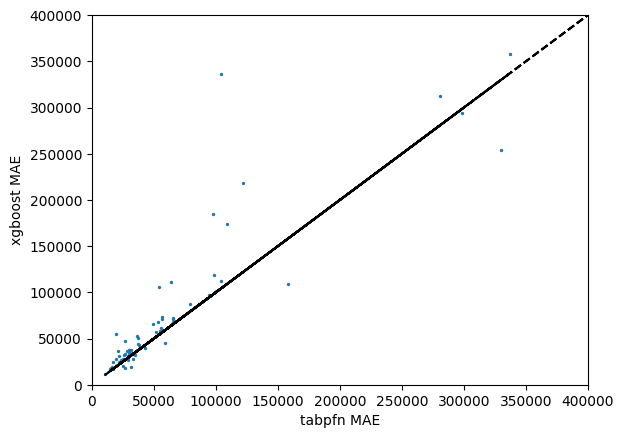

In [39]:
plt.scatter(df1['mae'], df2['mae'], s=2)
plt.plot(df1['mae'], df1['mae'], 'k--')
plt.xlabel('tabpfn MAE')
plt.ylabel('xgboost MAE')
plt.xlim(0, 0.4e6)
plt.ylim(0, 0.4e6)
plt.show()
# plt.scatter(df1['rmse'], df2['rmse'], s=2)
# plt.plot(df1['rmse'], df1['rmse'], 'k--')
# plt.xlabel('tabpfn RMSE')
# plt.ylabel('xgboost RMSE')

In [38]:
res1 = df1['mae'].describe()
res2 = df2['mae'].describe()

# put them together
res = pd.concat([res1, res2], axis=1)
res.columns = ['tabpfn', 'xgboost']

with pd.option_context('display.float_format', '{:,.6f}'.format):
    print(res)

                tabpfn          xgboost
count        64.000000        64.000000
mean     78,540.045875    92,377.071064
std     137,883.228713   150,779.890029
min      10,742.700391    11,523.641406
25%      26,274.372070    30,018.688086
50%      36,540.897453    44,371.926700
75%      65,262.277386    89,705.713412
max   1,006,592.707899 1,095,816.714410


In [41]:
df1['fips'].nunique(), df2['fips'].nunique()

(64, 64)

In [44]:
# get distribution of median sale price for each fips

fips_list = df1['fips'].unique()
list_of_median_sale_prices = []
for fips in df1['fips'].unique():
    df = pd.read_csv(f'/nlp/scr/salilg/county_csvs/fips_{fips}.csv')
    list_of_median_sale_prices.append(df['SALE_AMOUNT'].median())

saleprices = pd.DataFrame({'fips': fips_list, 'median_sale_price': list_of_median_sale_prices})


In [45]:
saleprices

,fips,median_sale_price
0,35019,162879.00
1,30051,145201.25
2,48045,81005.00
3,28041,53500.00
4,13101,72050.00
...,...,...
59,21189,25000.00
60,13265,90000.00
61,28061,71000.00
62,17069,66500.00


In [47]:
with pd.option_context('display.float_format', '{:,.6f}'.format):
    print(saleprices['median_sale_price'].describe())

count        64.000000
mean    114,670.364219
std      94,742.389259
min      20,750.000000
25%      59,556.250000
50%      81,252.500000
75%     136,190.375000
max     467,780.000000
Name: median_sale_price, dtype: float64
